# A4 - Dataset 3: Poland OLX House Price

- **Dạng dữ liệu:** tabular.
- **Task:** regression.
- **CNN:** Conv1D trên chuỗi feature (teaching experiment).
- **Basic CNN:** `Conv1D -> ReLU -> Conv1D -> ReLU -> MaxPool1D -> Flatten -> Dense(1)`
- **Xử lý dữ liệu sửa:** dùng `log1p(price)` để giảm ảnh hưởng của phân phối giá lệch phải/outlier cực lớn.
- **Output:** Linear.
- **Metrics:** MAE, RMSE, R², Loss vs Epoch.


> **Phạm vi A4 notebook này bao phủ:** Load dataset → Basic/Discover CNN → Improved CNN → CNN From Scratch → PyTorch → TensorFlow → Train/Evaluate/Compare.
>
> **Lưu ý:** bảng giao bài không quy định cụ thể “Improved CNN” phải dùng kỹ thuật nào. Trong notebook này, bản Improved dùng thêm filters/layer và BatchNorm/Dropout ở framework như một phương án cải tiến hợp lý; phần From Scratch tập trung đúng mục tiêu bài giảng là tự cài convolution, forward/backprop và cập nhật tham số.
>
> Notebook đặt trong `ASignment4/notebooks/`; dữ liệu ở `../data/`, model ở `../models/`, kết quả ở `../results/`.

In [1]:
from pathlib import Path
import random,warnings,re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib

SEED=42
random.seed(SEED)
np.random.seed(SEED)

ROOT=Path("..")
DATA_DIR=ROOT/"data"
MODEL_DIR=ROOT/"models"
RESULT_DIR=ROOT/"results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

TRAIN_LIMIT=None

## 1. Load dữ liệu và xử lý leakage/outlier theo log-target

In [2]:
df=pd.read_csv(DATA_DIR/"house.csv")
print("Shape:",df.shape)
display(df.head())

def norm_name(s):
    return re.sub(r"[^a-z0-9]","",str(s).lower())

norm_map={norm_name(c):c for c in df.columns}
target_col=norm_map.get("price")
if target_col is None:
    hits=[c for c in df.columns if "price" in c.lower() and "meter" not in c.lower()]
    if len(hits)!=1:
        raise ValueError(f"Không xác định target price: {hits}")
    target_col=hits[0]

if not pd.api.types.is_numeric_dtype(df[target_col]):
    cleaned=(df[target_col].astype(str)
             .str.replace(r"[^0-9,.-]","",regex=True)
             .str.replace(",",".",regex=False))
    df[target_col]=pd.to_numeric(cleaned,errors="coerce")

df=df.dropna(subset=[target_col]).copy()
df=df[df[target_col]>0].copy()

print("Target:",target_col)
print(df[target_col].describe())

Shape: (62818, 16)


,offer_title,price,price_per_meter,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,year,population,longitude,latitude
0,Kawalerka na sprzedaĹĽ,240000.0,8888.89,Private,1.0,27.00,1,Housing Block,primary,BolesĹ‚awiec,Lower Silesia,January,2022,39603,15.565105,51.263033
1,Nowoczesna kawalerka z winda plus garaĹĽ podzi...,250000.0,7142.86,Private,1.0,35.00,1,Housing Block,primary,Jelcz-Laskowice,Lower Silesia,January,2022,15828,17.349964,51.039831
2,Nowa kawalerka z Balkonem/Legnicka/Magnolia,259000.0,10360.00,Estate Agency,2.0,25.00,1,Housing Block,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978
3,Kawalerka z balkonem/klucze I kwartaĹ‚ 2022/60...,269000.0,10275.02,Private,3.0,26.18,1,Apartment Building,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978
4,40 tys. taniej od dewelopera/Kawalerka/Magnoli...,258000.0,9923.08,Estate Agency,3.0,26.00,1,Housing Block,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978


Target: price
count    6.281800e+04
mean     3.994059e+05
std      2.023251e+06
min      1.000000e+00
25%      2.600000e+05
50%      3.450000e+05
75%      4.600000e+05
max      5.041516e+08
Name: price, dtype: float64


In [3]:
X_df=df.drop(columns=[target_col]).copy()
y_price=df[target_col].to_numpy(dtype=np.float64)

# Loại cột gây leakage trực tiếp từ price
leak_cols=[]
for c in X_df.columns:
    n=norm_name(c)
    if "pricepermeter" in n or "pricepersqm" in n or "pricepersquare" in n:
        leak_cols.append(c)

# Loại cột text/id có cardinality cực cao
high_card=[]
for c in X_df.select_dtypes(include=["object","string"]).columns:
    nu=X_df[c].nunique(dropna=True)
    if nu>1000 or nu>0.5*len(X_df):
        high_card.append(c)

drop_cols=sorted(set(leak_cols+high_card))
print("Drop:",drop_cols)

X_df=X_df.drop(columns=drop_cols,errors="ignore").dropna(axis=1,how="all")

X_train_df,X_test_df,y_train_price,y_test_price=train_test_split(
    X_df,y_price,test_size=0.2,random_state=SEED
)

num_cols=X_train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=[c for c in X_train_df.columns if c not in num_cols]

for c in num_cols:
    med=X_train_df[c].median()
    X_train_df[c]=X_train_df[c].fillna(med)
    X_test_df[c]=X_test_df[c].fillna(med)

for c in cat_cols:
    X_train_df[c]=X_train_df[c].astype("string").fillna("missing")
    X_test_df[c]=X_test_df[c].astype("string").fillna("missing")

pre=ColumnTransformer([
    ("num",StandardScaler(),num_cols),
    ("cat",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1),cat_cols),
])

X_train=pre.fit_transform(X_train_df).astype(np.float32)
X_test=pre.transform(X_test_df).astype(np.float32)

feature_scaler=StandardScaler()
X_train=feature_scaler.fit_transform(X_train).astype(np.float32)
X_test=feature_scaler.transform(X_test).astype(np.float32)

# SỬA QUAN TRỌNG: log1p price trước khi chuẩn hóa target
y_train_log=np.log1p(y_train_price)
y_test_log=np.log1p(y_test_price)

y_scaler=StandardScaler()
y_train=y_scaler.fit_transform(y_train_log.reshape(-1,1)).ravel().astype(np.float32)
y_test=y_scaler.transform(y_test_log.reshape(-1,1)).ravel().astype(np.float32)

X_train_ncl=X_train[:,None,:]
X_test_ncl=X_test[:,None,:]

print("Train:",X_train_ncl.shape)
print("Test :",X_test_ncl.shape)

joblib.dump(pre,MODEL_DIR/"house_preprocessor_fixed.joblib")
joblib.dump(feature_scaler,MODEL_DIR/"house_feature_scaler_fixed.joblib")
joblib.dump(y_scaler,MODEL_DIR/"house_target_log_scaler_fixed.joblib")

Drop: ['offer_title', 'price_per_meter']
Train: (50254, 1, 13)
Test : (12564, 1, 13)


['..\\models\\house_target_log_scaler_fixed.joblib']

## 2. CNN From Scratch

Bản Scratch: `Conv1 -> ReLU -> Conv2 -> ReLU -> Pool -> Flatten -> Dense(linear)`

Loss dùng MSE trên **log-price đã chuẩn hóa**.  
Khi đánh giá, dự đoán được biến đổi ngược bằng `inverse StandardScaler -> expm1` để MAE/RMSE trở lại đơn vị giá gốc.

In [4]:
from numpy.lib.stride_tricks import sliding_window_view

def take_limit(X,y,limit):
    if limit is None or limit>=len(X):
        return X,y
    return X[:limit],y[:limit]

X_fit,y_fit=take_limit(X_train_ncl,y_train,TRAIN_LIMIT)

class Conv1DSameManual:
    def __init__(self,in_channels,out_channels,kernel_size=3,seed=42):
        rng=np.random.default_rng(seed)
        self.k=kernel_size
        self.pad=kernel_size//2
        self.W=(rng.standard_normal((out_channels,in_channels,kernel_size))
                *np.sqrt(2/(in_channels*kernel_size))).astype(np.float32)
        self.b=np.zeros(out_channels,dtype=np.float32)

    def forward(self,x):
        self.x=x
        p=self.pad
        self.xp=np.pad(x,((0,0),(0,0),(p,p)),mode="constant")
        windows=sliding_window_view(self.xp,self.k,axis=2)
        return np.einsum("nclk,fck->nfl",windows,self.W)+self.b[None,:,None]

    def backward(self,dout,lr):
        windows=sliding_window_view(self.xp,self.k,axis=2)
        dW=np.einsum("nfl,nclk->fck",dout,windows)
        db=dout.sum(axis=(0,2))
        dxp=np.zeros_like(self.xp)
        L=dout.shape[2]
        for j in range(self.k):
            dxp[:,:,j:j+L]+=np.einsum("nfl,fc->ncl",dout,self.W[:,:,j])
        p=self.pad
        dx=dxp[:,:,p:-p] if p>0 else dxp
        self.W-=lr*dW
        self.b-=lr*db
        return dx

class DenseManual:
    def __init__(self,in_dim,out_dim=1,seed=42):
        rng=np.random.default_rng(seed)
        self.W=(rng.standard_normal((in_dim,out_dim))*np.sqrt(2/in_dim)).astype(np.float32)
        self.b=np.zeros(out_dim,dtype=np.float32)
    def forward(self,x):
        self.x=x
        return x@self.W+self.b
    def backward(self,dout,lr):
        dx=dout@self.W.T
        self.W-=lr*(self.x.T@dout)
        self.b-=lr*dout.sum(axis=0)
        return dx


class MaxPool1DManual:
    def forward(self, x):
        self.x = x
        N, C, L = x.shape
        L2 = L // 2
        x_crop = x[:, :, :L2*2]
        xr = x_crop.reshape(N, C, L2, 2)
        self.maxv = xr.max(axis=3, keepdims=True)
        self.crop_shape = x_crop.shape
        return self.maxv.squeeze(3)

    def backward(self, dout):
        x = self.x
        N, C, L = x.shape
        L2 = L // 2
        x_crop = x[:, :, :L2*2]
        xr = x_crop.reshape(N, C, L2, 2)
        mask = xr == self.maxv
        denom = mask.sum(axis=3, keepdims=True)
        dxr = mask * (dout[:, :, :, None] / denom)
        dx = np.zeros_like(x)
        dx[:, :, :L2*2] = dxr.reshape(self.crop_shape)
        return dx

class ManualHouseCNN:
    def __init__(self,L,seed=42):
        self.conv1=Conv1DSameManual(1,8,3,seed)
        self.conv2=Conv1DSameManual(8,8,3,seed+1)
        self.pool=MaxPool1DManual()
        self.fc=DenseManual(8*(L//2),1,seed+2)

    def forward(self,x):
        self.z1=self.conv1.forward(x)
        self.h1=np.maximum(self.z1,0)
        self.z2=self.conv2.forward(self.h1)
        self.h2=np.maximum(self.z2,0)
        self.p=self.pool.forward(self.h2)
        self.pool_shape=self.p.shape
        return self.fc.forward(self.p.reshape(len(x),-1)).ravel()

    def train_batch(self,x,y,lr):
        pred=self.forward(x)
        n=len(y)
        err=pred-y
        loss=float(np.mean(err**2))
        dp=(2*err/n)[:,None]

        dpool=self.fc.backward(dp,lr).reshape(self.pool_shape)
        dh2=self.pool.backward(dpool)
        dz2=dh2*(self.z2>0)
        dh1=self.conv2.backward(dz2,lr)
        dz1=dh1*(self.z1>0)
        self.conv1.backward(dz1,lr)
        return loss

    def predict(self,X,batch_size=1024):
        out=[]
        for s in range(0,len(X),batch_size):
            out.append(self.forward(X[s:s+batch_size]))
        return np.concatenate(out)

def train_manual(model,X,y,epochs=12,batch_size=512,lr=0.002):
    rng=np.random.default_rng(SEED)
    hist=[]
    for ep in range(epochs):
        order=rng.permutation(len(X))
        ls=[]
        for s in range(0,len(X),batch_size):
            b=order[s:s+batch_size]
            ls.append(model.train_batch(X[b],y[b],lr))
        hist.append(float(np.mean(ls)))
        print(f"Epoch {ep+1}/{epochs} - MSE={hist[-1]:.4f}")
    return hist

def inverse_price(y_scaled):
    log_price=y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1,1)).ravel()
    return np.expm1(log_price)

def reg_metrics(pred_scaled):
    true_price=inverse_price(y_test)
    pred_price=inverse_price(pred_scaled)
    mae=mean_absolute_error(true_price,pred_price)
    rmse=mean_squared_error(true_price,pred_price)**0.5
    r2=r2_score(true_price,pred_price)
    return mae,rmse,r2

In [5]:
manual=ManualHouseCNN(X_train_ncl.shape[2],SEED)
scratch_loss=train_manual(manual,X_fit,y_fit,epochs=12,batch_size=512,lr=0.002)

scratch_pred=manual.predict(X_test_ncl)
scratch_mae,scratch_rmse,scratch_r2=reg_metrics(scratch_pred)

print(f"Scratch MAE={scratch_mae:,.2f} | RMSE={scratch_rmse:,.2f} | R2={scratch_r2:.4f}")

np.savez(
    MODEL_DIR/"house_scratch_fixed.npz",
    conv1_W=manual.conv1.W,conv1_b=manual.conv1.b,
    conv2_W=manual.conv2.W,conv2_b=manual.conv2.b,
    fc_W=manual.fc.W,fc_b=manual.fc.b
)

Epoch 1/12 - MSE=1.1279
Epoch 2/12 - MSE=0.8965
Epoch 3/12 - MSE=0.8270
Epoch 4/12 - MSE=0.7568
Epoch 5/12 - MSE=0.7237
Epoch 6/12 - MSE=0.7010
Epoch 7/12 - MSE=0.6856
Epoch 8/12 - MSE=0.6728
Epoch 9/12 - MSE=0.6660
Epoch 10/12 - MSE=0.6570
Epoch 11/12 - MSE=0.6532
Epoch 12/12 - MSE=0.6458
Scratch MAE=104,674.44 | RMSE=193,717.83 | R2=0.3323


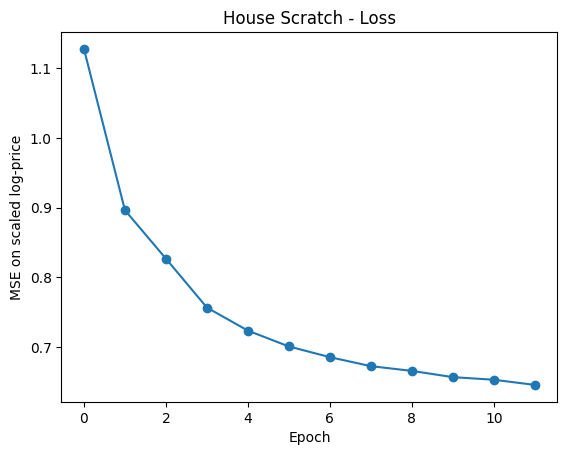

In [6]:
plt.plot(scratch_loss,marker="o")
plt.xlabel("Epoch");plt.ylabel("MSE on scaled log-price")
plt.title("House Scratch - Loss")
plt.show()

## 3. PyTorch

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

torch.manual_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xpt,ypt=take_limit(X_train_ncl,y_train,TRAIN_LIMIT)
tr_loader=DataLoader(
    TensorDataset(torch.tensor(Xpt,dtype=torch.float32),
                  torch.tensor(ypt,dtype=torch.float32)),
    batch_size=512,shuffle=True
)
te_loader=DataLoader(
    TensorDataset(torch.tensor(X_test_ncl,dtype=torch.float32),
                  torch.tensor(y_test,dtype=torch.float32)),
    batch_size=1024,shuffle=False
)

L=X_train_ncl.shape[2]

class TorchBasic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,8,3,padding=1),nn.ReLU(),
            nn.Conv1d(8,8,3,padding=1),nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear(8*(L//2),1)
        )
    def forward(self,x):
        return self.net(x).squeeze(1)

class TorchImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,16,3,padding=1),
            nn.BatchNorm1d(16),nn.ReLU(),
            nn.Conv1d(16,32,3,padding=1),
            nn.BatchNorm1d(32),nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.20),
            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.net(x).squeeze(1)

def train_pt(model,epochs=12):
    model=model.to(device)
    loss_fn=nn.MSELoss()
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    hist=[]
    for ep in range(epochs):
        model.train();ls=[]
        for xb,yb in tr_loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad()
            pred=model(xb)
            loss=loss_fn(pred,yb)
            loss.backward()
            opt.step()
            ls.append(loss.item())
        hist.append(float(np.mean(ls)))
        print(f"Epoch {ep+1}/{epochs} - MSE={hist[-1]:.4f}")
    return model,hist

def eval_pt(model):
    model.eval();out=[]
    with torch.no_grad():
        for xb,_ in te_loader:
            out.append(model(xb.to(device)).cpu().numpy())
    pred=np.concatenate(out)
    return pred,*reg_metrics(pred)

In [8]:
pt_basic,pt_basic_loss=train_pt(TorchBasic(),12)
_,pt_basic_mae,pt_basic_rmse,pt_basic_r2=eval_pt(pt_basic)

pt_imp,pt_imp_loss=train_pt(TorchImproved(),12)
_,pt_imp_mae,pt_imp_rmse,pt_imp_r2=eval_pt(pt_imp)

print("PyTorch Basic   :",pt_basic_mae,pt_basic_rmse,pt_basic_r2)
print("PyTorch Improved:",pt_imp_mae,pt_imp_rmse,pt_imp_r2)

torch.save(pt_basic.state_dict(),MODEL_DIR/"house_pytorch_basic_fixed.pth")
torch.save(pt_imp.state_dict(),MODEL_DIR/"house_pytorch_improved_fixed.pth")

Epoch 1/12 - MSE=0.8827
Epoch 2/12 - MSE=0.7154
Epoch 3/12 - MSE=0.6447
Epoch 4/12 - MSE=0.6112
Epoch 5/12 - MSE=0.5862
Epoch 6/12 - MSE=0.5752
Epoch 7/12 - MSE=0.5664
Epoch 8/12 - MSE=0.5600
Epoch 9/12 - MSE=0.5740
Epoch 10/12 - MSE=0.5514
Epoch 11/12 - MSE=0.5518
Epoch 12/12 - MSE=0.5508
Epoch 1/12 - MSE=0.8951
Epoch 2/12 - MSE=0.8223
Epoch 3/12 - MSE=0.7593
Epoch 4/12 - MSE=0.7150
Epoch 5/12 - MSE=0.6943
Epoch 6/12 - MSE=0.6759
Epoch 7/12 - MSE=0.6606
Epoch 8/12 - MSE=0.6588
Epoch 9/12 - MSE=0.6458
Epoch 10/12 - MSE=0.6390
Epoch 11/12 - MSE=0.6353
Epoch 12/12 - MSE=0.6297
PyTorch Basic   : 91978.75 179407.34290435273 0.4272889494895935
PyTorch Improved: 115989.203125 213501.21820729735 0.18893468379974365


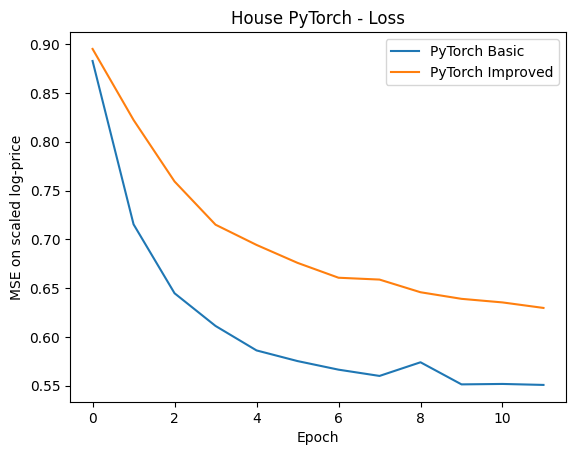

In [9]:
plt.plot(pt_basic_loss,label="PyTorch Basic")
plt.plot(pt_imp_loss,label="PyTorch Improved")
plt.xlabel("Epoch");plt.ylabel("MSE on scaled log-price")
plt.title("House PyTorch - Loss")
plt.legend();plt.show()

## 4. TensorFlow/Keras

In [10]:
import tensorflow as tf
tf.random.set_seed(SEED)

Xtf=np.transpose(Xpt,(0,2,1))
Xtest_tf=np.transpose(X_test_ncl,(0,2,1))

def tf_basic_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((L,1)),
        tf.keras.layers.Conv1D(8,3,padding="same",activation="relu"),
        tf.keras.layers.Conv1D(8,3,padding="same",activation="relu"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])

def tf_improved_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((L,1)),
        tf.keras.layers.Conv1D(16,3,padding="same"),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.Conv1D(32,3,padding="same"),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(1)
    ])

def train_tf(model,epochs=12):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="mse")
    h=model.fit(
        Xtf,ypt,validation_split=0.1,
        epochs=epochs,batch_size=512,verbose=2
    )
    return model,h

In [11]:
tf_basic,tf_basic_hist=train_tf(tf_basic_model(),12)
tf_imp,tf_imp_hist=train_tf(tf_improved_model(),12)

tf_basic_pred=tf_basic.predict(Xtest_tf,verbose=0).ravel()
tf_imp_pred=tf_imp.predict(Xtest_tf,verbose=0).ravel()

tf_basic_mae,tf_basic_rmse,tf_basic_r2=reg_metrics(tf_basic_pred)
tf_imp_mae,tf_imp_rmse,tf_imp_r2=reg_metrics(tf_imp_pred)

print("TF Basic   :",tf_basic_mae,tf_basic_rmse,tf_basic_r2)
print("TF Improved:",tf_imp_mae,tf_imp_rmse,tf_imp_r2)

tf_basic.save(MODEL_DIR/"house_tensorflow_basic_fixed.keras")
tf_imp.save(MODEL_DIR/"house_tensorflow_improved_fixed.keras")

Epoch 1/12
89/89 - 1s - 15ms/step - loss: 0.9196 - val_loss: 0.8025
Epoch 2/12
89/89 - 0s - 4ms/step - loss: 0.7440 - val_loss: 0.6878
Epoch 3/12
89/89 - 0s - 3ms/step - loss: 0.6720 - val_loss: 0.6375
Epoch 4/12
89/89 - 0s - 3ms/step - loss: 0.6353 - val_loss: 0.6096
Epoch 5/12
89/89 - 0s - 3ms/step - loss: 0.6137 - val_loss: 0.5923
Epoch 6/12
89/89 - 0s - 3ms/step - loss: 0.5981 - val_loss: 0.5793
Epoch 7/12
89/89 - 0s - 3ms/step - loss: 0.5869 - val_loss: 0.5705
Epoch 8/12
89/89 - 0s - 3ms/step - loss: 0.5792 - val_loss: 0.5638
Epoch 9/12
89/89 - 0s - 3ms/step - loss: 0.5730 - val_loss: 0.5577
Epoch 10/12
89/89 - 0s - 3ms/step - loss: 0.5677 - val_loss: 0.5524
Epoch 11/12
89/89 - 0s - 2ms/step - loss: 0.5632 - val_loss: 0.5483
Epoch 12/12
89/89 - 0s - 3ms/step - loss: 0.5597 - val_loss: 0.5446
Epoch 1/12
89/89 - 2s - 17ms/step - loss: 1.0141 - val_loss: 0.9452
Epoch 2/12
89/89 - 0s - 4ms/step - loss: 0.8495 - val_loss: 0.8795
Epoch 3/12
89/89 - 0s - 4ms/step - loss: 0.8068 - val_los

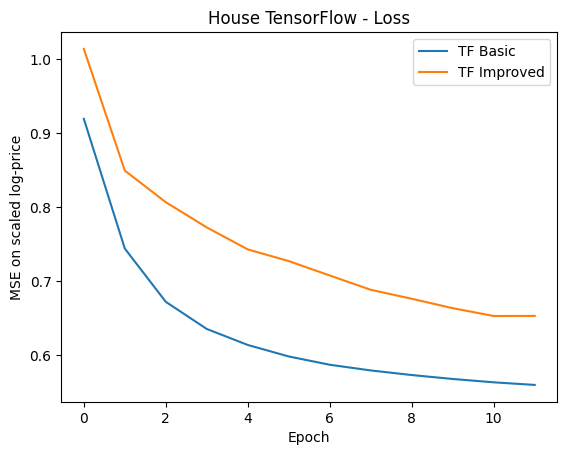

In [12]:
plt.plot(tf_basic_hist.history["loss"],label="TF Basic")
plt.plot(tf_imp_hist.history["loss"],label="TF Improved")
plt.xlabel("Epoch");plt.ylabel("MSE on scaled log-price")
plt.title("House TensorFlow - Loss")
plt.legend();plt.show()

## 5. Bảng so sánh

In [13]:
house_results=pd.DataFrame([
    ["NumPy From Scratch","Basic",scratch_mae,scratch_rmse,scratch_r2],
    ["PyTorch","Basic",pt_basic_mae,pt_basic_rmse,pt_basic_r2],
    ["PyTorch","Improved",pt_imp_mae,pt_imp_rmse,pt_imp_r2],
    ["TensorFlow","Basic",tf_basic_mae,tf_basic_rmse,tf_basic_r2],
    ["TensorFlow","Improved",tf_imp_mae,tf_imp_rmse,tf_imp_r2],
],columns=["Implementation","Model","MAE","RMSE","R2"])

display(house_results)
house_results.to_csv(RESULT_DIR/"house_comparison_fixed.csv",index=False)

,Implementation,Model,MAE,RMSE,R2
0,NumPy From Scratch,Basic,104674.437500,193717.829928,0.332280
1,PyTorch,Basic,91978.750000,179407.342904,0.427289
2,PyTorch,Improved,115989.203125,213501.218207,0.188935
3,TensorFlow,Basic,92905.656250,178673.867636,0.431962
4,TensorFlow,Improved,99345.296875,189242.946162,0.362772


### Nhận xét khi báo cáo
House Price có phân phối giá lệch phải rất mạnh. `log1p(price)` không xóa dữ liệu mà chỉ nén khoảng cách giữa các giá cực lớn, giúp quá trình tối ưu ổn định hơn. Khi đánh giá, kết quả đã được biến đổi ngược về đơn vị giá gốc.